# Data Science in Psychology and Neuroscience

## Class info:
* Week #10
* Day: March 26, 2026
* Time: 9:30—10:45 AM
* Location: Logan Hall 125
* <a href="https://forms.microsoft.com/r/26vAcJWrwH">Click here to submit your attendance for Week 10, Question 18!</a>
  
## Instructor info:
* Dr. Jeremy Hogeveen
* jhogeveen@unm.edu
* Logan Hall 281 (Office Hours By Appointment)
  
## Syllabus:
* <a href="https://www.dropbox.com/scl/fi/6fs6fi4kvkwtxn7j7x8ua/PSY450650_DSPN_Spring2026_Syllabus.pdf?rlkey=148e5t4ah8q2n1daclt7mp0h6&dl=0">Download here</a>

## Today's topic:
* Difference models!
    1. Read in example data (ketamine trial, fake data)
    2. Simple difference tests (paired, independent samples)
    3. Three-level difference tests
       * One-way ANOVA
       * Repeated-measures ANOVA
    4. Three by three mixed ANOVA
 

# Section 1: Ketamine for depression example.

## 1.1 Clinical trials as an example where "difference tests rule supreme" 
* Let's say you are interested in examining the effects of ketamine on depression.
* Question: Does ketamine lower depression scores on clinician administered Hamilton Depression scale (HAM-D)?
    * Hypothesis: Ketamine results in rapid (immediately post-infusion) and lasting (6-months followup) reductions in depression relative to both an active (amphetamine infusion) and passive (placebo/saline infusion) control condition.

<img src="img/ketamine_bookCover.jpg" width=250>

## 1.2 Reading in our (fake) sample data.

In [4]:
suppressPackageStartupMessages(library(tidyverse))
suppressPackageStartupMessages(library(rstatix))
suppressPackageStartupMessages(library(afex))
suppressPackageStartupMessages(library(emmeans))
suppressPackageStartupMessages(library(knitr))

df <- read_csv('../data/synth_ketamine_data.csv') # replace with full path to your data file...

#reorder the factor levels in my data frame
desired_order <- c("Pre","Post","Followup")
df$Time <- factor(df$Time,levels = desired_order)

head(df)

Rows: 180 Columns: 5
── Column specification ────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Drug, Time
dbl (3): Subject, Change, HAMD

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Subject,Drug,Change,Time,HAMD
<dbl>,<chr>,<dbl>,<fct>,<dbl>
1,Ketamine,10.89830,Pre,28.112875
1,Ketamine,10.89830,Post,17.214579
1,Ketamine,10.89830,Followup,15.227329
2,Ketamine,12.55569,Pre,22.305905
2,Ketamine,12.55569,Post,9.750214
2,Ketamine,12.55569,Followup,7.809342


* Difference models!
    1. ~~Read in example data (ketamine trial, fake data)~~
    2. Simple difference tests (paired, independent samples)
    3. Three-level difference tests
       * One-way ANOVA
       * Repeated-measures ANOVA
    4. Three by three mixed ANOVA

# Section 2. Testing for simple differences between 2 groups or 2 conditions.

## 2.1 Is there a difference between the ketamine and amphetamine groups in terms of baseline depression levels?

Drug,variable,n,mean,sd
<chr>,<fct>,<dbl>,<dbl>,<dbl>
Amphetamine,HAMD,20,23.187,3.329
Ketamine,HAMD,20,24.576,3.938


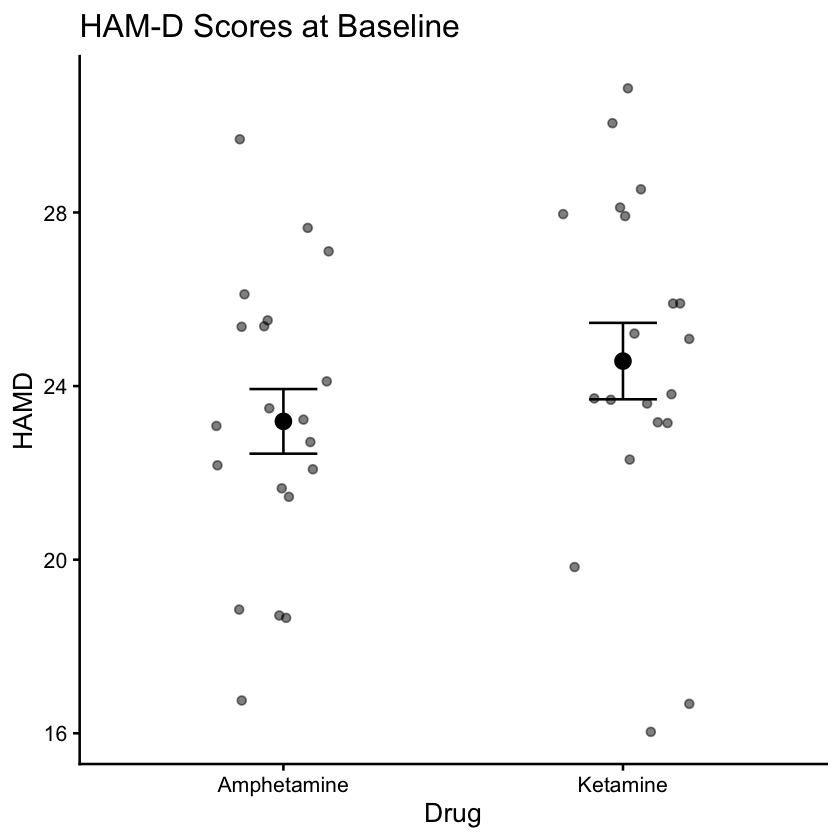

In [13]:
# filter our data down to only the baseline ketamine and amphetamine data
df_baseline_test <- df %>%
    filter(Drug %in% c("Ketamine","Amphetamine"),
          Time == "Pre")
# df_baseline_test

# get descriptives via rstatix
df_baseline_test %>%
    group_by(Drug) %>%
    # get_summary_stats(HAMD, type = "mean_ci")
    get_summary_stats(HAMD, type = "mean_sd")

# Visualiuze the data
p_baselinedepression_test <- ggplot(df_baseline_test,aes(Drug, y = HAMD)) +
    geom_jitter(width = 0.2, size=2, alpha = 0.5) +
    geom_errorbar(stat = "summary", fun.data = mean_se, width=0.2) +
    geom_point(stat = "summary", fun = mean, size=4) +
    theme_classic(base_size = 16) +
    ggtitle("HAM-D Scores at Baseline")
plot(p_baselinedepression_test)


In [21]:
# # basic rstatix ttest syntax
# model_object <- input_data %>%
#     t_test(formula = outcome ~ twolevel_predictor,
#            paired = TRUE/FALSE,
#            var.equal = TRUE/FALSE,
#            detailed = TRUE/FALSE
#            )

# model with an independent sample t-test
m_baseline_test <- df_baseline_test %>%
    t_test(HAMD ~ Drug,
           paired = FALSE,
           var.equal = TRUE,
           detailed = TRUE) %>%
    add_significance()

# # interrogating the output
# print(m_baseline_test)
# t_stat <- m_baseline_test %>% select(statistic)
# print(t_stat)
# p_sig <- m_baseline_test %>% select(p.signif)
# print(p_sig)

# render a clean HTML table and round to 3 decimals
kable(m_baseline_test,digits = 3, caption = "HTML-ready independent t-test table")



Table: HTML-ready independent t-test table

| estimate| estimate1| estimate2|.y.  |group1      |group2   | n1| n2| statistic|     p| df| conf.low| conf.high|method |alternative |p.signif |
|--------:|---------:|---------:|:----|:-----------|:--------|--:|--:|---------:|-----:|--:|--------:|---------:|:------|:-----------|:--------|
|   -1.389|    23.187|    24.576|HAMD |Amphetamine |Ketamine | 20| 20|    -1.204| 0.236| 38|   -3.723|     0.945|T-test |two.sided   |ns       |

## 2.2 Is there a difference between the ketamine group's pre versus posttest depression levels?

Time,variable,n,mean,ci
<fct>,<fct>,<dbl>,<dbl>,<dbl>
Pre,HAMD,20,24.576,1.843
Post,HAMD,20,12.094,2.206


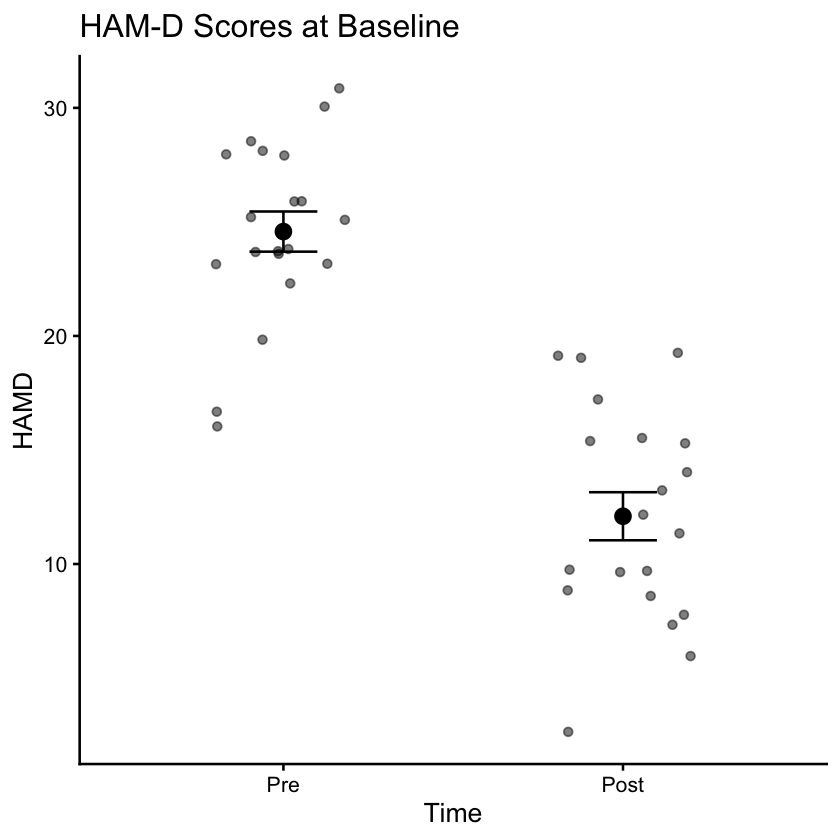

In [25]:
# filter to the data we need
df_prepost <- df %>%
    filter(Drug == "Ketamine",
           Time %in% c("Pre","Post"))
# df_prepost

# get descriptives via rstatix
df_prepost %>%
    group_by(Time) %>%
    get_summary_stats(HAMD, type="mean_ci")

# Visualizing the data
p_prepost_test <- ggplot(df_prepost,aes(x = Time, y = HAMD)) +
    geom_jitter(width = 0.2, size=2, alpha = 0.5) +
    geom_errorbar(stat = "summary", fun.data = mean_se, width=0.2) +
    geom_point(stat = "summary", fun = mean, size=4) +
    theme_classic(base_size = 16) +
    ggtitle("HAM-D Scores at Baseline")
plot(p_prepost_test)

In [27]:
# model with an paired sample t-test
m_prepost_test <- df_prepost %>%
    t_test(HAMD ~ Time,
           paired = TRUE,
           var.equal = TRUE,
           detailed = TRUE) %>%
    add_significance()

kable(m_prepost_test,digits = 3, caption = "HTML-ready paired t-test table")



Table: HTML-ready paired t-test table

| estimate|.y.  |group1 |group2 | n1| n2| statistic|  p| df| conf.low| conf.high|method |alternative |p.signif |
|--------:|:----|:------|:------|--:|--:|---------:|--:|--:|--------:|---------:|:------|:-----------|:--------|
|   12.482|HAMD |Pre    |Post   | 20| 20|    22.884|  0| 19|    11.34|    13.623|T-test |two.sided   |****     |

* Difference models!
    1. ~~Read in example data (ketamine trial, fake data)~~
    2. ~~Simple difference tests (paired, independent samples)~~
    3. Three-level difference tests
       * One-way ANOVA
       * Repeated-measures ANOVA
    4. Three by three mixed ANOVA

# Section 3. Testing three-level, single factor differences between (one-way ANOVA) or within (repeated-measures ANOVA) subjects.

## 3.1 Are there a differences in the pre-posttest HAMD changes between ketamine, amphetamine, _and_ placebo?

Drug,variable,n,mean,ci
<chr>,<fct>,<dbl>,<dbl>,<dbl>
Amphetamine,Change,20,6.246,1.289
Ketamine,Change,20,12.482,1.142
Placebo,Change,20,2.046,1.458


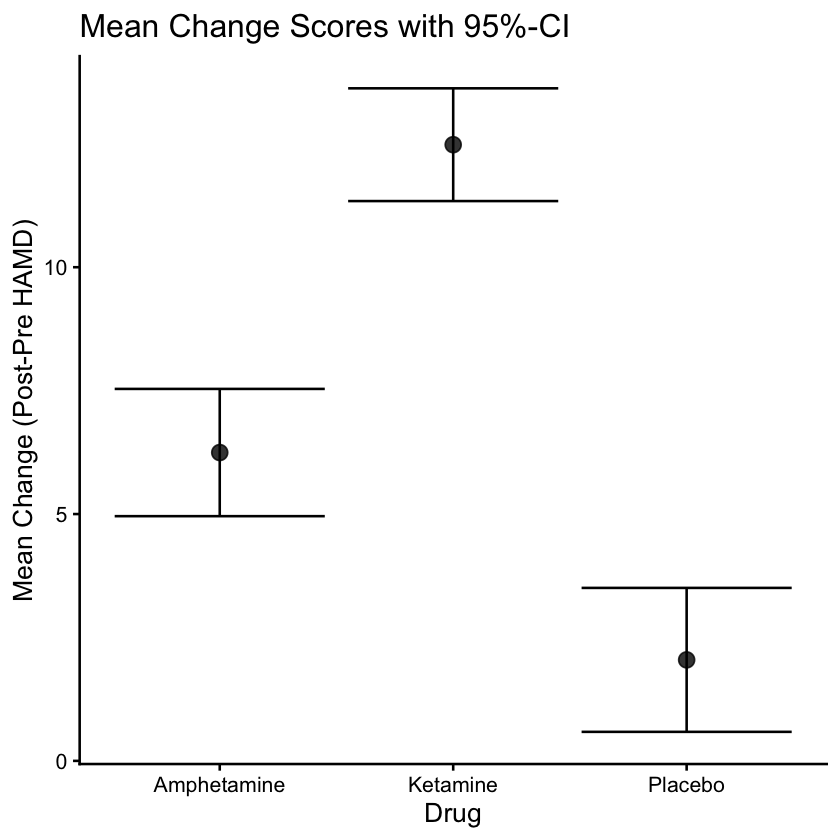

In [30]:
# shift the daat from long to wide format
df_wide <- df %>%
    pivot_wider(names_from = Time, values_from=HAMD) %>%
    relocate(Change,.after=last_col()) #%>%
    # mutate(change = post - pre)

# print descriptives
df_oneway <- df_wide %>%
    group_by(Drug) %>%
    get_summary_stats(Change, type = "mean_ci")
df_oneway

# visualize change scores by drug condition
p_oneway <- ggplot(df_oneway,aes(x = Drug, y = mean)) +
    geom_errorbar(aes(ymin = mean - ci, ymax = mean + ci)) +
    geom_point(size = 4, alpha=0.8) +
    theme_classic(base_size=16) +
    ylab("Mean Change (Post-Pre HAMD)") +
    ggtitle("Mean Change Scores with 95%-CI")
p_oneway

In [36]:
# # basic anovas using afex
# model_object <- aov_ez(
#     id = "subject_id",
#     dv = "dependent_variable".
#     data = your_df,
#     between = c("between_factor"),
#     within = c("within_factor"))

# run the one way anova
head(df_wide)
m_change <- aov_ez(id = "Subject",
                   dv = "Change",
                   data = df_wide,
                   between = "Drug")
summary(m_change)

# expected marginal means contrasts, w tukey adjustment for multiple comparisons
means_oneway <- emmeans(m_change, pairwise ~ Drug, adjust = "tukey")
kable(means_oneway$contrasts, digits = 3, caption = "Post-Hoc Tests from One-Way ANOVA")

Subject,Drug,Pre,Post,Followup,Change
<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,Ketamine,28.11288,17.214579,15.227329,10.898296
2,Ketamine,22.30591,9.750214,7.809342,12.555692
3,Ketamine,25.08939,11.343914,12.593319,13.745471
4,Ketamine,25.89859,9.699377,8.706099,16.199210
5,Ketamine,25.21280,15.394681,16.391036,9.818124
6,Ketamine,23.68163,7.773999,7.917481,15.907628


Converting to factor: Drug

Contrasts set to contr.sum for the following variables: Drug



,num Df,den Df,MSE,F,ges,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Drug,2,57,7.747696,71.17443,0.7140691,3.187439e-16




Table: Post-Hoc Tests from One-Way ANOVA

|contrast               | estimate|   SE| df| t.ratio| p.value|
|:----------------------|--------:|----:|--:|-------:|-------:|
|Amphetamine - Ketamine |   -6.236| 0.88| 57|  -7.085|       0|
|Amphetamine - Placebo  |    4.200| 0.88| 57|   4.771|       0|
|Ketamine - Placebo     |   10.436| 0.88| 57|  11.856|       0|

## 3.2 Are there differences between the pre, post, _and_ followup HAMD changes in the ketamine group.

* Difference models!
    1. ~~Read in example data (ketamine trial, fake data)~~
    2. ~~Simple difference tests (paired, independent samples)~~
    3. ~~Three-level difference tests~~
       ~~* One-way ANOVA~~
       ~~* Repeated-measures ANOVA~~
    4. Three by three mixed ANOVA

# Section 4. Are there differences in the _lasting_ antidepressant effects of ketamine versus amphetamine versus placebo?

## 4.1 Running a `3 (time: pre, posttest, followup)` x `3 (drug: ketamine, amphetamine, placebo)` Mixed ANOVA